# ML Assignment 1
Iciar Adeliño - March 2026 - Machine Learning Foundations

## Task Ordering

1. **Identifying the prediction target**:
   We must first define what we are predicting. The target determines the task type, evaluation metrics, and which features are valid at prediction time.

2. **Data loading and exploration**:
   This step is descriptive and safe before splitting. It helps us understand variable types, distributions, missing values, and potential class imbalance without fitting any transformations.

3. **Data splitting (stratified)**:
   Splitting must occur before any transformation that learns from data to prevent leakage. Train, validation, and test sets must remain statistically independent.

4. **Managing missing values**:
   Imputation relies on distributional statistics, so it must be fitted on the training set and then applied to validation and test sets.

5. **Encoding categorical variables**:
   Future steps require numerical input.

6. **Feature scaling**:
   Scaling improves optimization and coefficient comparability.

7. **Feature selection**:
   Now that the featurs are finalized, we can select the relvant ones for our model. 

8. **Addressing class imbalance**:
   Resampling must operate on the fully engineered feature space, so we do it after all feature engineering.

9. **Training**:
   We train the model on the processed training set, validate performance on the validation set, and use the test set only once for final evaluation.


## Imports

In [27]:
# import everything at the top
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# to avoid output getting cut off
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)


## Identifying prediction target 

In [2]:
# check the first five rows to see the columns in the dataset
df = pd.read_csv("bank-additional.csv", sep=";")
print(df.head())

   age          job  marital          education default  housing     loan  \
0   30  blue-collar  married           basic.9y      no      yes       no   
1   39     services   single        high.school      no       no       no   
2   25     services  married        high.school      no      yes       no   
3   38     services  married           basic.9y      no  unknown  unknown   
4   47       admin.  married  university.degree      no      yes       no   

     contact month day_of_week  duration  campaign  pdays  previous  \
0   cellular   may         fri       487         2    999         0   
1  telephone   may         fri       346         4    999         0   
2  telephone   jun         wed       227         1    999         0   
3  telephone   jun         fri        17         3    999         0   
4   cellular   nov         mon        58         1    999         0   

      poutcome  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
0  nonexistent          -1.8        

The target variable is `y`. It indicates whether a client subscribed to a term deposit (`"yes"` or `"no"`). It is the appropriate prediction objective for this marketing campaign for the following reasons:

- The entire campaign exists to identify clients likely to subscribe to a term deposit, which what `y` directly encodes.
- `y` is not observed until the client makes their decision at the end of the call, it is the event we are trying to anticipate.
- There are only two values for `y` which makes sense, knowing that what we are trying to predict is whether they subscribe or not. 

Variables that could superficially appear to be valid targets:

1. `duration` — last contact duration in seconds

Call duration is strongly correlated with the subscription outcome, as longer calls tend to result in a subscription. It seems to reflect the outcome of the interaction. However, it is not exactly what we are trying to precict. It is not binary and a longer call does not necessarily mean a successful subscription.

2. `poutcome` — outcome of the previous marketing campaign

This variable encodes success/failure so it might look like what we have to predict. However, `poutcome` refers to a past campaign, not the current one, which is not our objective.

## Data loading and exploration 

Lets find the number of observations, number of features and data types:

In [3]:
print("Dataset shape:", df.shape)
print("\nData types:", df.dtypes)

Dataset shape: (4119, 21)

Data types: age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object


Find numerical vs categorical features:

In [4]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["str"]).columns.tolist()

print("Numerical features:", numerical_cols)
print("\nCategorical features:", categorical_cols)

Numerical features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


Find some basic statistics on the features:

In [5]:
print("\nBasic summary statistics (numerical):")
print(df.describe())

print("\nBasic summary statistics (categorical):")
print(df.describe(include="str"))


Basic summary statistics (numerical):
               age     duration     campaign        pdays     previous  \
count  4119.000000  4119.000000  4119.000000  4119.000000  4119.000000   
mean     40.113620   256.788055     2.537266   960.422190     0.190337   
std      10.313362   254.703736     2.568159   191.922786     0.541788   
min      18.000000     0.000000     1.000000     0.000000     0.000000   
25%      32.000000   103.000000     1.000000   999.000000     0.000000   
50%      38.000000   181.000000     2.000000   999.000000     0.000000   
75%      47.000000   317.000000     3.000000   999.000000     0.000000   
max      88.000000  3643.000000    35.000000   999.000000     6.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx    euribor3m  nr.employed  
count   4119.000000     4119.000000    4119.000000  4119.000000  4119.000000  
mean       0.084972       93.579704     -40.499102     3.621356  5166.481695  
std        1.563114        0.579349       4.594578     1.

Check if all values for months are present:

In [6]:
print(df["month"].value_counts().sort_index())

month
apr     215
aug     636
dec      22
jul     711
jun     530
mar      48
may    1378
nov     446
oct      69
sep      64
Name: count, dtype: int64


Check for class imbalance:

This can affect how we choose evaluation metrics later on. Because accuracy can be misleading in imbalanced datasets. 

y
no     3668
yes     451
Name: count, dtype: int64
y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


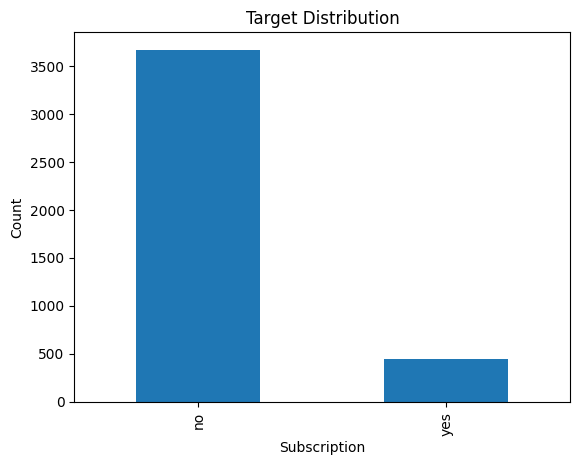

In [7]:
target_col = "y"
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True))

# Plot target distribution
df[target_col].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

Check for missing values (we only check for "unknown" because missingness is not represented any other way):

In [8]:
# explicit
print("Explicit:")
print(df.isnull().sum())

# implicit
print("Implicit:")
# categorical 
suspicious_strings = ["unknown", "na", "n/a", ""]

for col in df.select_dtypes(include="str").columns:
    unique_vals = df[col].astype(str).str.lower().unique()
    for val in suspicious_strings:
        if val in unique_vals:
            print(f"Column '{col}' contains implicit missing value: '{val}'")

# numeric 
suspicious_numbers = [999, -1, 9999, -999]

for col in df.select_dtypes(include="number").columns:
    for num in suspicious_numbers:
        count = (df[col] == num).sum()
        if count > 0:
            print(f"Column '{col}' contains {count} occurrences of suspicious value: {num}")

Explicit:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
Implicit:
Column 'job' contains implicit missing value: 'unknown'
Column 'marital' contains implicit missing value: 'unknown'
Column 'education' contains implicit missing value: 'unknown'
Column 'default' contains implicit missing value: 'unknown'
Column 'housing' contains implicit missing value: 'unknown'
Column 'loan' contains implicit missing value: 'unknown'
Column 'duration' contains 1 occurrences of suspicious value: 999
Column 'pdays' contains 3959 occurrences of suspicious value: 999


Check the distribution of some numerical features for skewness or outliers:

- We check `age` because subscription likelihood may vary across age groups. Maybe scaling is needed. 

- We check `campaign` because it might be skewed so it may require some transformations, and extreme values may influence linear models. 

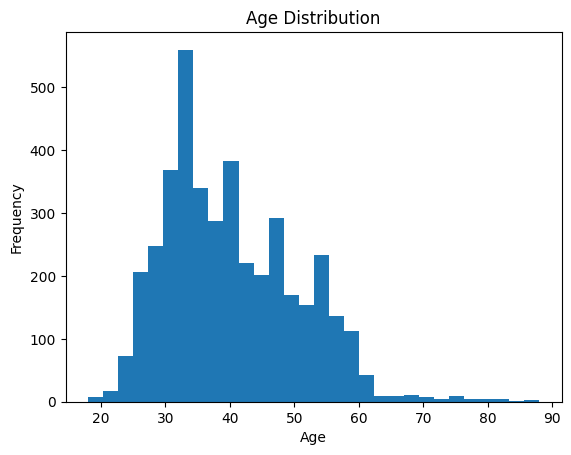

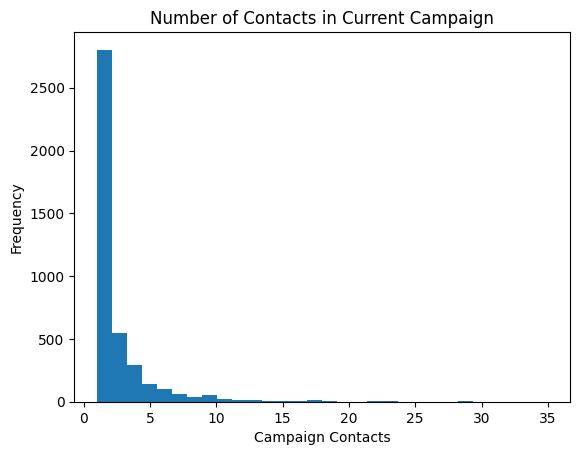

In [9]:
# Age distribution
plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Campaign distribution
plt.hist(df["campaign"], bins=30)
plt.title("Number of Contacts in Current Campaign")
plt.xlabel("Campaign Contacts")
plt.ylabel("Frequency")
plt.show()

We also inspect the distribution of categorical variables to check for long tail categories, class imbalance, and to decide an encoding strategy. 

- We check `job` because it is liekly predictive of the target variable, and has many categories so is risky of having long tail.

- We check `contact` to check if the distribution is even.


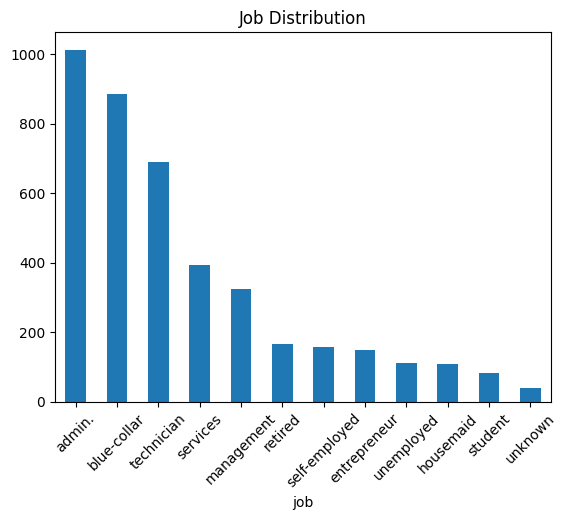

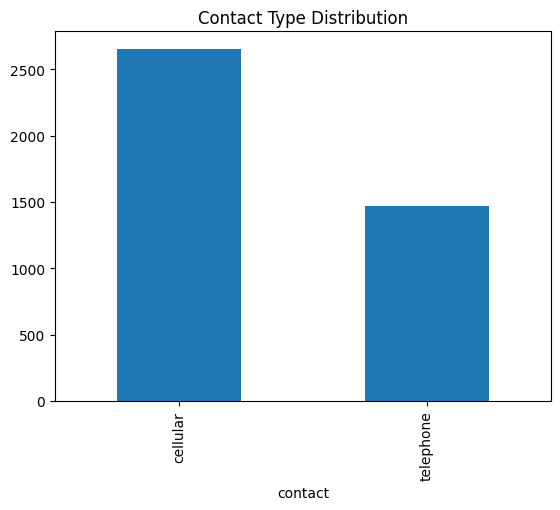

In [10]:
# Job
df["job"].value_counts().plot(kind="bar")
plt.title("Job Distribution")
plt.xticks(rotation=45)
plt.show()

# Contact type
df["contact"].value_counts().plot(kind="bar")
plt.title("Contact Type Distribution")
plt.show()

Finally we check if there are any leakage variables:

`duration` is duration of the last call in seconds, which is only know after the call ends, and not at prediciton time. using it would result in temporal leakage, so we will remove it.  

### Conclusions

So some conclusions after data exploration:

- **Size and types**: 4119 observations, 10 numerical features, 10 categorical features, 1 binary target (`y`).
- **Class imbalance**: ~89% "no" vs ~11% "yes". Accuracy alone is misleading; metrics like F1, recall, or ROC-AUC are more appropriate.
- **No explicit missing values**, but six categorical columns (`job`, `marital`, `education`, `default`, `housing`, `loan`) contain `"unknown"` as an implicit placeholder for missingness and two numerical columns (`duration` and `pdays`) contain `999`.
- **Skewed features**: `campaign` is heavily right-skewed with extreme values (max 35), which may affect linear models and suggests a log transform or clipping could help.
- **Categorical imbalance**: `contact` is dominated by "cellular"; `job` has a long tail of rare categories. This informs encoding choices.
- **Data leakage**: `duration` (last call length in seconds) is only known after the call ends and must be dropped before training.

## Data splitting

Before splitting we remove `duration` from the full dataset.  

In [11]:
# remove duration and target variable before splitting
drop_cols = ["duration"]
X = df.drop(columns=[target_col] + drop_cols)
y = df[target_col]

# to check it was correct
print("X shape:", X.shape)
print("Y shape:", y.shape)

X shape: (4119, 19)
Y shape: (4119,)


In [12]:
# split train and temporary first
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40, # 40% goes to temporary
    random_state=22, # (2 is my favorite number)
    stratify=y
)

print("Train shape:", X_train.shape)
print("Temp shape:", X_temp.shape)

# split temporary into test and validation
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,       # split 40% into 20% val and 20% test
    random_state=22,
    stratify=y_temp
)

print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# check class proportions
print("Train:\n", y_train.value_counts(normalize=True))
print("Validation:\n", y_val.value_counts(normalize=True))
print("Test:\n", y_test.value_counts(normalize=True))

Train shape: (2471, 19)
Temp shape: (1648, 19)
Validation shape: (824, 19)
Test shape: (824, 19)
Train:
 y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64
Validation:
 y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64
Test:
 y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64


### Some explanations

**- Proportions:**

The dataset is not small enough for cross-validation, but is also not big enough to have small percentages for holdout sets. 60/20/20 is a balanced approach with enough training data, enough validation data to tune and enough test data for a reliable final estimate. 

**- Stratification:** 

As we saw in the data loading phase, our target variable y is really imbalanced, there are many "no" and a few "yes". By strafying we ensure the same class proportions in all sets so that training is realistic, validation is meaningful and performance metrics don't get distorted. 

**- Randomness and reproducibility:**

Adding a seed makes the split repetable, which makes sure the whole pipeline stays reproducible. 

**- Why here in the pipeline:**

Splitting the dataset should happen after loading and basic inspection of the data and before any preprocessing transformations. Many preprocessing steps compute statistics from the data, and if these are computed using the full dataset, information from validation and test sets leaks into training data (data leakage), so the model indirectly sees the test and validation distribution. This would result in optimistically biased evaluation. Different types of leakage could occur: 
1. Statistical leakage: if statistics are calculated using entire data
2. Imputation leakage: if missing values are filled using global mean/median/mode computed 
3. Encoding leakage: if you do mean target encoding using the full dataset you are using test labels to encode training features
4. Feature selection leakage: if you use Boruta on full dataset 
5. Data augmentation leakage: if synthetic points are generated before splitting they may be derived from samples that appear later in test

## Managing missing values

We performed missing value analysis in the initial exploratory analysis, but we will do it again on the training data only to ensure pipeline integrity and make sure that any transformations are exclusively based on training set (values might differ slightly). For example, no need to worry about `duration` because it was removed. 

In [13]:
# no need to compute explicit cause there are none present in the whole dataset

# implicit categorical
suspicious_strings = ["unknown", "na", "n/a", ""]

for col in X_train.select_dtypes(include="str").columns:
    unique_vals = X_train[col].astype(str).str.lower().unique()
    for val in suspicious_strings:
        if val in unique_vals:
            print(f"Column '{col}' contains implicit missing value: '{val}'")

# implicit numeric sentinel values
suspicious_numbers = [999, -1, 9999, -999]

for col in X_train.select_dtypes(include="number").columns:
    for num in suspicious_numbers:
        count = (X_train[col] == num).sum()
        if count > 0:
            print(f"Column '{col}' contains {count} occurrences of suspicious value: {num}")

Column 'job' contains implicit missing value: 'unknown'
Column 'marital' contains implicit missing value: 'unknown'
Column 'education' contains implicit missing value: 'unknown'
Column 'default' contains implicit missing value: 'unknown'
Column 'housing' contains implicit missing value: 'unknown'
Column 'loan' contains implicit missing value: 'unknown'
Column 'pdays' contains 2383 occurrences of suspicious value: 999


Lets see how many times `unknown` appears for categorical variables:

In [14]:
cat_cols = X_train.select_dtypes(include=["str"]).columns
unknown_counts = (X_train[cat_cols].astype("string").apply(lambda s: (s.str.lower() == "unknown").sum()))
print(unknown_counts)

job             27
marital          5
education      102
default        491
housing         61
loan            61
contact          0
month            0
day_of_week      0
poutcome         0
dtype: int64


### Numerical variable

The number `999` in `pdays` represents the fact that that customer has never been contacted before. And this is the case for most of the customers in the dataset (2383 out of 2471 customers).

We will split this attribute into two features: `never_contacted` and `pdays_days`.

- `never_contacted` will be a binary flag indicating if the customer has never been contacted. So it equals 1 when `pdays` was 999 previously. 

- `pdays_days` will be the days since last contact. Whenever it was `999` in the past we will set it to `NaN` and later impute those values. 

For the imputation we can use the median as it is robust to outliers and works well in most situations. 

Justification:

- This approach matches reality really nicely, as it reflects two different regimes: contacted and not contacted. 

- Logistic regression benefits of this as it can assign separate weights, one for never contacted and one for how long ago. 

- Avoids giving the model a misleading geometry where 999 is far away from all other values.

- Explicitly models missingness and signals this is a special case. 

In [15]:
def transform_pdays(df, median_pdays=None):
    df = df.copy()

    # binary flag
    df["never_contacted"] = (df["pdays"] == 999).astype(int)

    # numeric days since last contact (set 999 -> nan)
    df["pdays_days"] = df["pdays"].replace(999, np.nan)

    # fit on train only, reuse for validation/test
    if median_pdays is None:
        median_pdays = df.loc[df["never_contacted"] == 0, "pdays_days"].median()

    df["pdays_days"] = df["pdays_days"].fillna(median_pdays)

    # drop original pdays column to avoid confusion
    df = df.drop(columns=["pdays"])

    return df, median_pdays

# fit on training data
X_train, median_pdays = transform_pdays(X_train)

# check
print(X_train[["never_contacted", "pdays_days"]].head())
print("Median used for imputation:", median_pdays)
print("Remaining NaNs in pdays_days:", X_train["pdays_days"].isna().sum())

      never_contacted  pdays_days
1952                1         6.0
3044                1         6.0
3381                1         6.0
1713                0         6.0
3776                1         6.0
Median used for imputation: 6.0
Remaining NaNs in pdays_days: 0


In [16]:
# apply training median to validation and test data
X_val, _ = transform_pdays(X_val, median_pdays=median_pdays)
X_test, _ = transform_pdays(X_test, median_pdays=median_pdays)

### Categorical variables

The features `job, marital, education, default, housing, loan` all have some `unknown` values. The missingness of these values can be informative and helpful for the model, it is not just random noise. People who don't disclose some data may behave differently, so we want to keep this information. 

We will do one-hot encoding for all nominal categorical features. So for example, instead of `loan = yes, no, unknown` we will have `loan_yes`, `loan_no` and `loan_unknown`. 

Justification:

- Missing values can provide useful information.

- Imputing would invent information that we don't have. 

- Dropping the rows with `unknown` is not doable because it would mean loosing a lot of rows.

However, because for all rows one of these three columns will be 1, we should drop one of them to avoid collinearity of inputs. We can treat the one we dropped as the baseline and the interpretation of coefficients becomes the column compared to the baseline. We can do this by using `OneHotEncoder(drop="first")`.

We will perform this step in the next step. We will also see how to encode the other categorical varibales in the next step. 

## Encoding categorial variables

We identified all categorical features in the dataset previously:

    Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

We can distinguish three types:

- Nominal: 'job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome'

- Ordinal: 'education'

- Cyclical: 'month', 'day_of_week'

Logisitc regression needs numerical feature vectors so we need an encoding strategy for each variable.

### Nominal varibales

For nominal variables we will use one-hot encoding as we discussed above. Also, nominal categories have no numeric meaning, so integer codes would invent distances (which is bad for linear models). OHE also keeps the coefficients interpretable, as each coefficient simply compares the category against the baseline. 

In [17]:
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome']
nominal_cols = [c for c in nominal_cols if c in X_train.columns]  # safety

# everything else becomes numeric or left as-is
num_cols = [col for col in X_train.columns if col not in nominal_cols]

ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

X_train_nom = ohe.fit_transform(X_train[nominal_cols])
X_val_nom   = ohe.transform(X_val[nominal_cols])
X_test_nom  = ohe.transform(X_test[nominal_cols])

encoded_cols = ohe.get_feature_names_out(nominal_cols)

X_train_nom_df = pd.DataFrame(X_train_nom, columns=encoded_cols, index=X_train.index)
X_val_nom_df   = pd.DataFrame(X_val_nom, columns=encoded_cols, index=X_val.index)
X_test_nom_df  = pd.DataFrame(X_test_nom, columns=encoded_cols, index=X_test.index)

X_train = pd.concat([X_train[num_cols], X_train_nom_df], axis=1)
X_val   = pd.concat([X_val[num_cols], X_val_nom_df], axis=1)
X_test  = pd.concat([X_test[num_cols], X_test_nom_df], axis=1)
# check
print("encoded train shape:", X_train.shape)
print("encoded validation shape:", X_val.shape)
print("encoded test shape:", X_test.shape)
print("sample encoded columns:", list(encoded_cols[:100]))

encoded train shape: (2471, 36)
encoded validation shape: (824, 36)
encoded test shape: (824, 36)
sample encoded columns: ['job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'poutcome_nonexistent', 'poutcome_success']


This will increase the **dimensionality of the input** by increasing the column count to 36. Initially I was concerned this would make the dataset too sparse and increase the input dimensionality too much, but I found that 36 columns versus 2471 samples is still very reasonable, and sparsity is only an issue when we move into hundres/thousands of columns. 

Also another thing I found useful here is to check the number of columns is the number of columns we expect. Here is a breakdown on the columns:

- Started with 21 and removed `y` and `duration`, so 19 left
- Engineered `pdays`, so removed 1 column and added 2, so 20 columns now
- Encoding nominal variables means droppping the 7 of them (13) and adding the number of categories per column minus 1, so adding 23 total.
- This matches our expectation of 36 columns.

### Ordinal variable



The column `education` represents different levels of education where some can be higher than others, like `university.degree` is higher than `high.school`. For this reason, if we were to encode it using one-hot encoding we would loose this progression information and it would create lots of extra columns that would really increase the dimensionality of the input.

So instead we encode it using ordinal encoding. This approach:

- Respects the ordering of different levels of education.
- Keeps the input vector compact (one column instead of many one-hot ones)
- Works nicely with Logistic Regression because it allwos it to learn an "education" trend in a single coefficient. 

One thing to take into account is that ordinal encoding assumes that the spacing between levels is uniform, which is not exactly the case here. However, in this case it is not that important of a detail and won't affect the model noticeably. We can use this as a small inductive bias for this dataset. 

Also, as we saw in the "Managing missing values" section, education has some unknown values, which should not correspond to a level in the progression, but to a different value that indicates explicitly this value is missing. We cna encode `unknown` as `-1` 

In [18]:
# define the order
education_order = [
    "illiterate",
    "basic.4y",
    "basic.6y",
    "basic.9y",
    "high.school",
    "professional.course",
    "university.degree"
]

# build encoder: unknown/unseen -> -1
edu_encoder = OrdinalEncoder(
    categories=[education_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# fit on train only, transform val/test
edu_train = edu_encoder.fit_transform(X_train[["education"]])
edu_val   = edu_encoder.transform(X_val[["education"]])
edu_test  = edu_encoder.transform(X_test[["education"]])

# add as a new numeric feature
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train["education_ord"] = edu_train.astype(int)
X_val["education_ord"]   = edu_val.astype(int)
X_test["education_ord"]  = edu_test.astype(int)

# drop the original categorical column
X_train = X_train.drop(columns=["education"])
X_val   = X_val.drop(columns=["education"])
X_test  = X_test.drop(columns=["education"])

The number of columns stays the same after this encoding because we are removing the old education column and adding a new encoded one instead. 

### Cyclical variables

The `month` variable probably contains valueable information, so we want to keep it. However, insetad of using cyclical encoding we will use one-hot encoding for the following reeasons:

- Cyclical sin/cos assumes that the relationship between months is smooth and periodic: December and January would be interpreted as being as close as May and June. And also there is no reason to believe that January and June should be interpreted as opposites. 

- OHE makes no assumption on the relationship between months and lets the model learn each month's effect freely. 

- Macro-economic features like `emp.var.rate` already carry cyclic seasonal signal, so whatever high-level pattern exists in `month` is likely encoded there already. 

- As we saw in EDA, There are 2 months that don't appear on the data, so if we used cyclical encoding we would be implying realtionships between months we have no evidence for. 

- OHE is more interpretable, and column count is still manageable. 

In [19]:
month_ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

month_train = month_ohe.fit_transform(X_train[["month"]])
month_val   = month_ohe.transform(X_val[["month"]])
month_test  = month_ohe.transform(X_test[["month"]])

month_cols = month_ohe.get_feature_names_out(["month"])

month_train_df = pd.DataFrame(month_train, columns=month_cols, index=X_train.index)
month_val_df   = pd.DataFrame(month_val,   columns=month_cols, index=X_val.index)
month_test_df  = pd.DataFrame(month_test,  columns=month_cols, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=["month"]), month_train_df], axis=1)
X_val   = pd.concat([X_val.drop(columns=["month"]),   month_val_df],   axis=1)
X_test  = pd.concat([X_test.drop(columns=["month"]),  month_test_df],  axis=1)

print("shape after month encoding:", X_train.shape)
print("month columns added:", list(month_cols))

shape after month encoding: (2471, 44)
month columns added: ['month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep']


The variable `day_of_week` is a pretty weak signal. The effect of Monday vs Friday on subscription rate is basically unnoticable compared to other macro features in the dataset. Adding noise can be more harmful than helpful. 

Also, the cyclical nature of this variable is pretty questionable too. The business week Monday-Friday doesn't truly wrap around, Monday and Friday are not really adjacent. For these reasons I decided to drop this column entirely. 

In [20]:
X_train = X_train.drop(columns=["day_of_week"])
X_val   = X_val.drop(columns=["day_of_week"])
X_test  = X_test.drop(columns=["day_of_week"])

print("shape after dropping day_of_week:", X_train.shape)

shape after dropping day_of_week: (2471, 43)


Here is a breakdown of how the column count changed across all encoding steps:

- Started with 36 columns after nominal OHE
- Ordinal encoding of `education`: replaced 1 string column with 1 integer column, so still 36
- OHE of `month` with `drop="first"`: removed 1 column, added 9 (10 months present minus 1 dropped baseline), so 36 - 1 + 9 = 44
- Dropped `day_of_week`: removed 1 column, so 44 - 1 = 43
- This matches our expectation of 43 columns.

## Feature scaling

Not all features need scaling. After our preprocessing the dataset now has two kinds of columns:

- **Continuous and ordinal features**: `age`, `campaign`, `previous`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`, `pdays_days`, `education_ord`. These live on very different scales (`age` ranges 18–88 while `euribor3m` ranges 0.6–5.0). These require scaling.

- **Binary features**: `never_contacted` and all OHE columns (`job_*`, `marital_*`, `month_*`) already live in {0, 1}. Scaling them would add no benefit while destroying their natural 0/1 interpretation.

As a scaling method I chose standardization (StandardScaler). For each feature we subtract the training mean and divide by the training standard deviation, so each scaled feature has mean 0 and standard deviation 1.

We choose standardization over normalization for these reasons:

- Min-max normalization compresses all values into [0, 1] by anchoring to the minimum and maximum. A single outlier shifts every other value, distorting the whole feature. Standardization uses mean and standard deviation, which are far less sensitive to extremes.

- Logistic regression does not need inputs in [0, 1]. Standardization produces unbounded z-scores, which is fine and is in fact what the optimizer expects when working with normally distributed features.

- Standardization is the standard preprocessing choice for logistic regression, linear regression, and SVM. Min-max normalization is more common for neural networks or distance-based methods that expect inputs in a fixed range.

Why fit only on the training set:

The scaler must be fitted on the training set only and then applied to validation and test sets using those same training statistics. If we computed the mean and standard deviation from the full dataset, the training process would have indirect access to distributional information from the validation and test sets (statistical leakage), leading to optimistically biased evaluation metrics.

Feature scaling affects three things:

**1. Gradient-based optimization.** When features have very different ranges, the loss surface becomes a narrow elongated valley. Gradient descent struggles with this because it overshoots in one direction and crawls in another. After standardization all features have unit variance, so the surface is more balanced and the optimizer converges much faster.

**2. Coefficient comparability.** Each coefficient $\beta_j$ represents the change in log-odds per one-unit increase in feature $j$. Without scaling, one unit means something completely different across features, so comparing coefficients is meaningless. After standardization, one unit is one standard deviation for every feature, so $|\beta_j|$ actually tells you how important that feature is.

**3. Regularization.** L1/L2 penalties shrink coefficients that are large. Without scaling, features with a small raw range naturally end up with large coefficients and get penalized more than they should. Standardization makes the penalty fair across all features, so the regularization strength behaves consistently.

In [21]:
cols_to_scale = [
    "age", "campaign", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
    "pdays_days", "education_ord"
]

scaler = StandardScaler()

# fit on train only, transform val/test with the same statistics
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val[cols_to_scale]   = scaler.transform(X_val[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print("means used for scaling:", dict(zip(cols_to_scale, scaler.mean_.round(3))))
print("stds  used for scaling:", dict(zip(cols_to_scale, scaler.scale_.round(3))))
print("shape unchanged:", X_train.shape)

means used for scaling: {'age': np.float64(40.067), 'campaign': np.float64(2.498), 'previous': np.float64(0.18), 'emp.var.rate': np.float64(0.088), 'cons.price.idx': np.float64(93.579), 'cons.conf.idx': np.float64(-40.417), 'euribor3m': np.float64(3.636), 'nr.employed': np.float64(5166.927), 'pdays_days': np.float64(6.002), 'education_ord': np.float64(3.964)}
stds  used for scaling: {'age': np.float64(10.296), 'campaign': np.float64(2.635), 'previous': np.float64(0.51), 'emp.var.rate': np.float64(1.572), 'cons.price.idx': np.float64(0.583), 'cons.conf.idx': np.float64(4.626), 'euribor3m': np.float64(1.729), 'nr.employed': np.float64(73.485), 'pdays_days': np.float64(0.707), 'education_ord': np.float64(1.927)}
shape unchanged: (2471, 43)


## Feature selection

We have to do feature selection using the training set only for the same reason scaling must be: if we use the full dataset to decide which features to keep, we are letting information from the validation and test sets influence what goes into the model. That is leakage. For example, if we dropped a feature because it was highly correlated with the target across the full dataset, we would be using test-set labels to guide our feature choices, and evaluation would be overly optimistic.

### Features with low variance

If a feature has near-zero variance it means it carries almost no information. In other words, if a column is nearly constant, it cannot help separate classes. For logistic regression this is especially problematic because a near-constant feature will produce a numerically unstable coefficient, meaning that a tiny change in data can flip its sign.

For binary OHE features, variance equals $p(1-p)$ where $p$ is the proportion of 1s. A feature with a probability of $p = 0.01$ has variance $0.0099$, so we use a threshold of **0.01**: 

- First, 1% means roughly only 24 occurrences in 2471 training samples, which is far too few for the model to learn a reliable pattern. The coefficient would be estimated from a handful of examples and would be noisy. 

- For logistic regression specifically, a near-constant feature is not good. Because the loss gradient for that feature is always near zero, the optimizer can push its coefficient to extreme values without much penalty, causing numerical instability.

We already standardized continuous features to variance = 1, so they are not at risk.

In [22]:
variances = X_train.var()
low_var_cols = variances[variances < 0.01].index.tolist()

print("features with variance < 0.01:")
print(variances[low_var_cols].sort_values())

if low_var_cols:
    X_train = X_train.drop(columns=low_var_cols)
    X_val   = X_val.drop(columns=low_var_cols)
    X_test  = X_test.drop(columns=low_var_cols)
    print(f"\ndropped {len(low_var_cols)} column(s): {low_var_cols}")
else:
    print("\nno features dropped")

print("shape after low-variance removal:", X_train.shape)

features with variance < 0.01:
default_yes        0.000405
marital_unknown    0.002020
month_dec          0.005636
dtype: float64

dropped 3 column(s): ['marital_unknown', 'default_yes', 'month_dec']
shape after low-variance removal: (2471, 40)


We dropped three columns: `default_yes`, `marital_unknown`, and `month_dec`. The rarest is `default_yes`(less than 0.04% of rows), meaning almost nobody in the dataset has a credit default flagged as yes. Removing them doesn't hurt the model because the rare-category signal they carry is too weak to learn from, and they contribute more noise than information. The baseline for each (`default_no`, `marital_divorced`, `month_apr`) is still represented through the other columns in the group, so no information is lost.

### Highly correlated features

When two features are very highly correlated, they carry almost the same information. In logistic regression this causes multicollinearity. The model cannot assign individual coefficients to each feature in a reliable way because many combinations of coefficients produce nearly the same loss. Even with L2 regularization the coefficients can be unstable as small changes in training data can cause large swings in the coefficient estimates, hurting interpretability.

To check how correlated they are we do Pearson correlation. We only do it for continuous and ordinal features because correlation in OHE binary features is not a meaningful measure for sparse binary columns.

We use a threshold of **|r| > 0.85** (commonly used value). Above that the two features explain so much of the same variance that keeping both adds little signal while increasing instability. When a pair exceeds the threshold, we drop the one that is more correlated with the other features overall, keeping the more "independent" one.

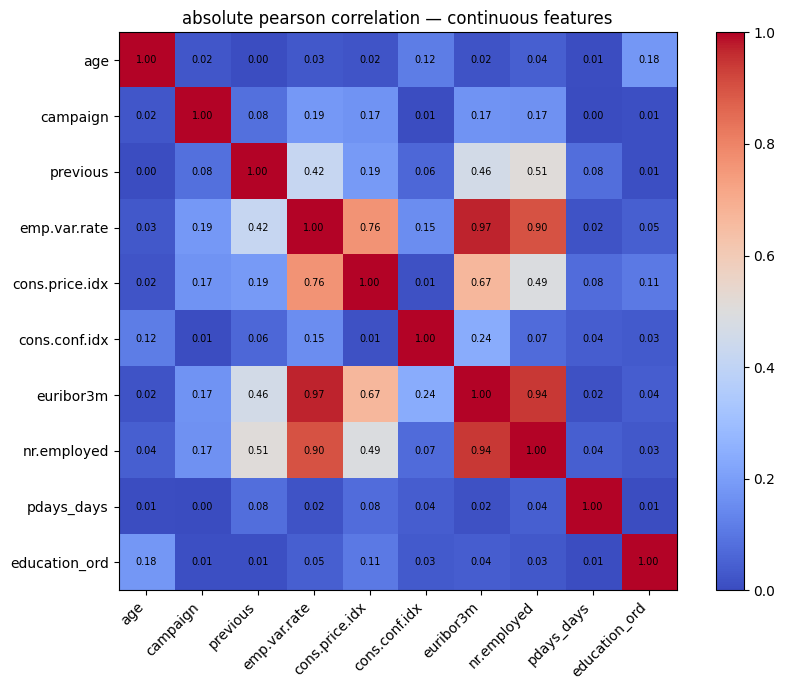

pairs with |r| > 0.85:
  emp.var.rate         — euribor3m             r = 0.970
  euribor3m            — nr.employed           r = 0.944
  emp.var.rate         — nr.employed           r = 0.900


In [23]:
cont_cols = ["age", "campaign", "previous", "emp.var.rate",
             "cons.price.idx", "cons.conf.idx", "euribor3m",
             "nr.employed", "pdays_days", "education_ord"]
cont_cols = [c for c in cont_cols if c in X_train.columns]  # safety after low-var removal

corr = X_train[cont_cols].corr().abs()

# plot heatmap
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, vmin=0, vmax=1, cmap="coolwarm")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(cont_cols)))
ax.set_yticks(range(len(cont_cols)))
ax.set_xticklabels(cont_cols, rotation=45, ha="right")
ax.set_yticklabels(cont_cols)
for i in range(len(cont_cols)):
    for j in range(len(cont_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.title("absolute pearson correlation — continuous features")
plt.tight_layout()
plt.show()

# identify pairs above threshold
threshold = 0.85
high_corr_pairs = [
    (cont_cols[i], cont_cols[j], corr.iloc[i, j])
    for i in range(len(cont_cols))
    for j in range(i + 1, len(cont_cols))
    if corr.iloc[i, j] > threshold
]
print(f"pairs with |r| > {threshold}:")
for a, b, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(f"  {a:20s} — {b:20s}  r = {r:.3f}")

As the matrix show, the macro-economic indicators `emp.var.rate`, `euribor3m`, and `nr.employed` are all very strongly correlated with one another. They all move together as they reflect the same underlying economic cycle. Keeping all three gives the model almost no extra information but inflates the feature space and destabilizes coefficients.

We choose to keep `euribor3m` and drop `emp.var.rate` and `nr.employed` for two reasons:
- `euribor3m` is measured daily (the finest resolution of the three) so it captures the economic state most precisely.
- It is the least correlated with the remaining features, so it is the most "independent" representative.

We keep `cons.price.idx` and `cons.conf.idx` because they measure different economic dimensions (inflation vs consumer sentiment) and are not strongly correlated with each other or with `euribor3m`.

In [24]:
cols_to_drop = ["emp.var.rate", "nr.employed"]
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]

X_train = X_train.drop(columns=cols_to_drop)
X_val   = X_val.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

print("dropped:", cols_to_drop)
print("shape after correlation removal:", X_train.shape)

dropped: ['emp.var.rate', 'nr.employed']
shape after correlation removal: (2471, 38)


It is important to mention here that in previous steps we did remove some other varibales:

- **`duration`** was removed before splitting. It records the length of the phone call in seconds, which is only known after the call ends (after the subscription decision has already been made). Using it would be direct temporal leakage.

- **`day_of_week`** was dropped during encoding. As discussed there, it is a very weak signal and the business week does not have a meaningful cyclical structure.

There are no other features are suspected to cause leakage. All remaining features (`age`, `job`, `marital`, `education`, contact history, and macro indicators) are observable before the call outcome is known.

## Addressing class imbalance

We already saw during EDA that the dataset is imbalanced: roughly 89% of clients did not subscribe and only 11% did. Because we used a stratified split, the training set preserves this ratio exactly.

In [25]:
counts = y_train.value_counts()
ratios = y_train.value_counts(normalize=True)
print("training set class counts:")
print(pd.DataFrame({"count": counts, "ratio": ratios.round(3)}))

training set class counts:
     count  ratio
y                
no    2200   0.89
yes    271   0.11


This imbalance is a problem. A model that always predicts `no` would reach 89% accuracy while being completely useless. The bank does not want to call everyone, it wants to identify the clients who will actually subscribe.

For this task, a false negative (predicting `no` for someone who would have subscribed) is worse than a false positive (predicting `yes` for someone who won't). Missing a potential subscriber means lost revenue; mistakenly targeting a non-subscriber just wastes a phone call.

This changes how we should read evaluation metrics:

- **Accuracy** is dominated by the majority class. A model that never predicts `yes` scores 89%, which looks good but is useless.
- **Recall** measures how many actual subscribers we caught. Low recall means we are missing potential customers — the costly mistake in this context.
- **Precision** measures how many of our predicted subscribers actually subscribe. Low precision means wasting campaign resources on people who will not subscribe.

### Resampling strategy: SMOTE

The best option in this case is using SMOTE (Synthetic Minority Oversampling Technique). Instead of simply duplicating existing minority-class samples, SMOTE generates new synthetic samples by interpolating between real minority-class examples in feature space. This is better because:

- This gives the model more diverse minority-class examples to learn from 
- It is less prone to overfitting than pure duplication

SMOTE must happen after splitting and only to the training set. If we apply it before splitting:

- If we resample the full dataset first, synthetic samples derived from what will become the test set get mixed into training data. The model then indirectly sees test-set patterns during training, which is leakage.
- Evaluation on the test set would be optimistically biased because the test distribution would no longer be truly independent.
- The reported metrics would not reflect real-world performance.

SMOTE is a good fit for logistic regression because logistic regression is a linear model that learns a decision boundary. With severely imbalanced data the boundary is pushed towards the minority class, causing the model to classify almost everything as `no`. Oversampling the minority class rebalances the training data and pulls the boundary back to a more sensible position.

An alternative would be ADASYN, which is similar to SMOTE but generates more synthetic samples near the decision boundary where the minority class is hardest to classify. For logistic regression it is actually a disadvantage. Those examples near the boundary are often noisy or ambiguous, and a linear model has no way to ignore it. It will try to fit those noisy samples and distort the decision boundary. SMOTE spreads synthetic samples more uniformly across the minority class distribution, which gives logistic regression a cleaner signal.

We keep the validation and test sets with the original class distribution on purpose because they represent what the model will face in the real world, so resampling them would give a false picture of performance.

In [ ]:

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("before SMOTE:", y_train.value_counts().to_dict())
print("after  SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

before SMOTE: {'no': 2200, 'yes': 271}
after  SMOTE: {'no': 2200, 'yes': 2200}


## Training

## Additional material

It is useful to understand what each column measures (found with some research):

| variable name    | role    | type        | description |
|------------------|---------|-------------|-------------|
| `age`            | feature | integer     | age of the client |
| `job`            | feature | categorical | type of job (admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown) |
| `marital`        | feature | categorical | marital status: married, divorced, single, unknown |
| `education`      | feature | categorical | education level: basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown |
| `default`        | feature | binary      | has credit in default? (yes / no / unknown) |
| `housing`        | feature | binary      | has a housing loan? (yes / no / unknown) |
| `loan`           | feature | binary      | has a personal loan? (yes / no / unknown) |
| `contact`        | feature | categorical | contact communication type: cellular or telephone |
| `month`          | feature | categorical | last contact month of the year (jan – dec) |
| `day_of_week`    | feature | categorical | last contact day of the week (mon – fri) |
| `duration`       | feature | integer     | last contact duration in seconds, only known after the call ends |
| `campaign`       | feature | integer     | number of contacts made to this client during this campaign |
| `pdays`          | feature | integer     | days since client was last contacted from a previous campaign (999 = never contacted before) |
| `previous`       | feature | integer     | number of contacts made to this client before this campaign |
| `poutcome`       | feature | categorical | outcome of the previous campaign: nonexistent, failure, success |
| `emp.var.rate`   | feature | continuous  | employment variation rate, quarterly macro indicator |
| `cons.price.idx` | feature | continuous  | consumer price index, monthly macro indicator |
| `cons.conf.idx`  | feature | continuous  | consumer confidence index, monthly macro indicator |
| `euribor3m`      | feature | continuous  | euribor 3-month interest rate, daily macro indicator |
| `nr.employed`    | feature | continuous  | number of employees in the economy — quarterly macro indicator |
| `y`              | target  | binary      | has the client subscribed to a term deposit? (yes / no) |